# Track 2 Data Investigator

**For:** learners comfortable with spreadsheets or a little Python. 

You will compare stream gauges, test how the selected time window changes a trend, and examine how chosen weights change a composite score. You will record both evidence and sensitivity.

**Output status:** classroom draft: do not distribute.

## Learning objectives

By the end of the hackathon, students should be able to:

1. **Frame a relevant question** about climate, agriculture or natural-resource stewardship and explain why it interests them.
2. **Use their selected notebook pathway** to explore environmental data, documenting what they tried and any challenges encountered.
3. **Interpret and communicate evidence**, explaining the source, location, time period and meaning of any results or visualizations they present.
4. **Recognize limitations and uncertainty**, distinguishing what the data show from what would require additional evidence.
5. **Propose a future project**, identifying a next question and the data, skills or partnerships needed to pursue it.
6. **Describe potential community benefits** and explain who might find the work useful.
7. **Identify appropriate reviewers or collaborators** and explain how their perspectives could improve interpretation and guide responsible sharing.

These objectives apply across all three tracks. Students demonstrate learning through their final presentations and explanations of completed or attempted work.

## Agricultural application

How can regional drought and streamflow records help frame questions about water availability, and what additional local evidence would we need?

Alternative questions may concern grazing, gardens, plant resources or watershed stewardship. State what additional evidence would be needed; regional indicators alone do not establish a management recommendation.

## 1. Choose the comparison

A comparison is useful only when its geographic fit, units, coverage, and missingness are understood. 

## Sovereignty activity 1: who shapes the question? (3-5 minutes)

Data sovereignty concerns Indigenous Peoples' authority over data relationships and uses. Data governance is how decisions about collection, interpretation, access and reuse are put into practice. For this exercise, the question itself is a decision: who chose it, whose priorities does it reflect, and who could change it?

With your group, identify a possible benefit, a role or body whose direction would be needed for a real project, and one kind of information you will **not** collect here. You can discuss a hypothetical situation without sharing personal, cultural or protected knowledge.

Start the decision notes below. Use role descriptions. `None` means unresolved. Keep sensitive answers outside this notebook in the appropriate setting. See [sovereignty practice](../guides/sovereignty_practice.md) for optional framework references.


In [1]:
# CUSTOMIZE: brief, non-sensitive discussion notes.
governance_notes = {
    "question": None,
    "potential_benefit": None,
    "authority_to_consult": None,
    "community_input_needed": None,
    "representation_limits": None,
    "reviewer_roles": None,
    "intended_audience": "agreed classroom audience; no public release assumed",
    "storage_and_access": None,
    "reuse_limits": "classroom exercise; revisit purpose and permissions before reuse",
    "correction_withdrawal": None,
    "decision": None,
    "decision_reason": None,
}
print("Start with question, benefit and authority to consult. Leave unknowns as None.")

Start with question, benefit and authority to consult. Leave unknowns as None.


In [2]:
# CUSTOMIZE HERE
TEAM_NAME = "Team Name Here"
EARLY_WINDOW = (1990, 2024)
LATE_WINDOW = (2005, 2024)
print(TEAM_NAME, EARLY_WINDOW, LATE_WINDOW)

Team Name Here (1990, 2024) (2005, 2024)


In [3]:
# Imports
from pathlib import Path
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

start = Path.cwd().resolve()
REPO = next((p for p in [start, *start.parents] if (p / "data").is_dir()), None)
DATA = REPO/"data"/"sample_or_fallback" if REPO else None
if DATA is None or not DATA.is_dir():
    raise RuntimeError("Fallback data folder not found. Ask an instructor to prepare it.")
print(f"READY! Using snapshots in {DATA.relative_to(REPO).as_posix()}")

READY! Using snapshots in data/sample_or_fallback


## 2. Load and audit streamflow

In [4]:
GAUGES = {
    "06446000": "White River Near Oglala SD",
    "06446500": "White River Near Interior SD",
    "06447000": "White River Near Kadoka SD",
    "06447500": "Little White River Near Martin SD",
}

def load_rdb(path, site_id, station):
    lines = [line for line in path.read_text(encoding="utf-8").splitlines() if not line.startswith("#")]
    header = lines[0].split("\t")
    rows = [line for line in lines[2:] if line.startswith("USGS")]
    frame = pd.read_csv(StringIO("\n".join(rows)), sep="\t", header=None, names=header, dtype=str)
    value_column = next(c for c in frame.columns if "00060" in c and not c.endswith("_cd"))
    return pd.DataFrame({
        "site_id": site_id, "station": station,
        "date": pd.to_datetime(frame["datetime"], errors="coerce"),
        "flow_cfs": pd.to_numeric(frame[value_column], errors="coerce"),
    }).dropna()

parts = []
for site_id, station in GAUGES.items():
    matches = sorted(DATA.glob(f"usgs_nwis_{site_id}_*.rdb"))
    if matches:
        parts.append(load_rdb(matches[-1], site_id, station))
flow = pd.concat(parts, ignore_index=True)
flow["year"] = flow["date"].dt.year
coverage = flow.groupby(["station", "year"]).agg(days=("date", "nunique"), mean_cfs=("flow_cfs", "mean")).reset_index()
coverage["complete_enough"] = coverage["days"] >= 330
coverage.groupby("station").agg(first_year=("year", "min"), last_year=("year", "max"), median_days=("days", "median"), usable_years=("complete_enough", "sum"))

,first_year,last_year,median_days,usable_years
station,,,,
Little White River Near Martin SD,1990,2024,365.0,35
White River Near Interior SD,2002,2024,365.0,22
White River Near Kadoka SD,1990,2024,365.0,35
White River Near Oglala SD,1990,2024,365.0,35


## Sovereignty activity 2: what does this data represent? (3-5 minutes)

Gauge placement determines which waters are represented. Which places and uses are missing from these four gauges? How might the 330-day rule, time-window choice or illustrative weights change the story told about a community? Identify one claim you would revise and one person/role whose interpretation you would seek. The score exercise expresses choices; it does not give a student team authority to rank community wellbeing.

Update `representation_limits` and `community_input_needed` below. 

In [5]:
# CUSTOMIZE after discussing representation. Use non-sensitive notes only.
governance_notes["representation_limits"] = None
governance_notes["community_input_needed"] = None

## 3. Compare gauges

This uses annual mean flow for a transparent first comparison.

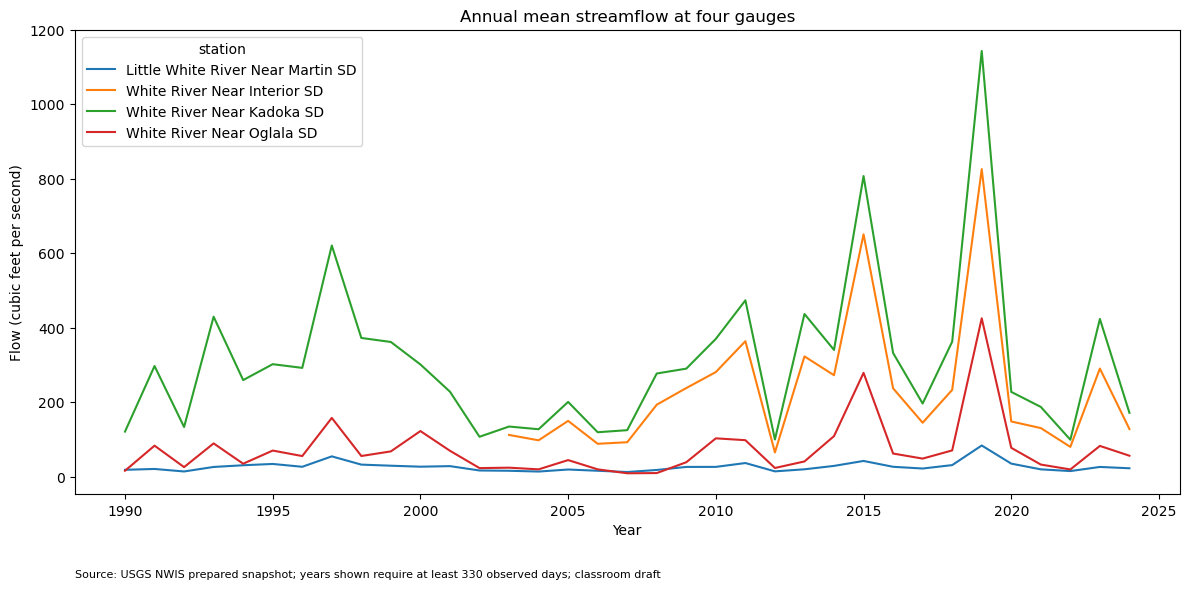

In [6]:
usable = coverage[coverage["complete_enough"]]
pivot = usable.pivot(index="year", columns="station", values="mean_cfs")
ax = pivot.plot(figsize=(12, 6), linewidth=1.5)
ax.set(title="Annual mean streamflow at four gauges", xlabel="Year", ylabel="Flow (cubic feet per second)")
ax.text(0, -0.18, "Source: USGS NWIS prepared snapshot; years shown require at least 330 observed days; classroom draft", transform=ax.transAxes, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Test time-window sensitivity

A trend is conditional on its selected period. Compare two defensible periods.

In [7]:
# CUSTOMIZE HERE: choose one gauge after examining coverage.
PRIMARY_GAUGE = "White River Near Oglala SD"

def trend_for_window(table, station, window):
    subset = table[(table["station"] == station) & table["complete_enough"] & table["year"].between(*window)]
    if len(subset) < 8:
        raise ValueError(f"Only {len(subset)} usable years in {window}")
    fit = stats.linregress(subset["year"], subset["mean_cfs"])
    return {"window": f"{window[0]}–{window[1]}", "usable_years": len(subset), "slope_cfs_decade": fit.slope * 10, "p_value": fit.pvalue}

sensitivity = pd.DataFrame([trend_for_window(coverage, PRIMARY_GAUGE, EARLY_WINDOW), trend_for_window(coverage, PRIMARY_GAUGE, LATE_WINDOW)])
sensitivity

,window,usable_years,slope_cfs_decade,p_value
0,1990–2024,35,15.913961,0.239078
1,2005–2024,20,39.373650,0.322252


Discuss: Did direction, magnitude, or p-value change? Which window better matches the community question, and why? A p-value does not measure importance, causality, or the probability that the claim is true.

## 5. Test weight sensitivity

These component values are deliberately labeled **illustrative**. The task is to understand how priorities affect a combined number.

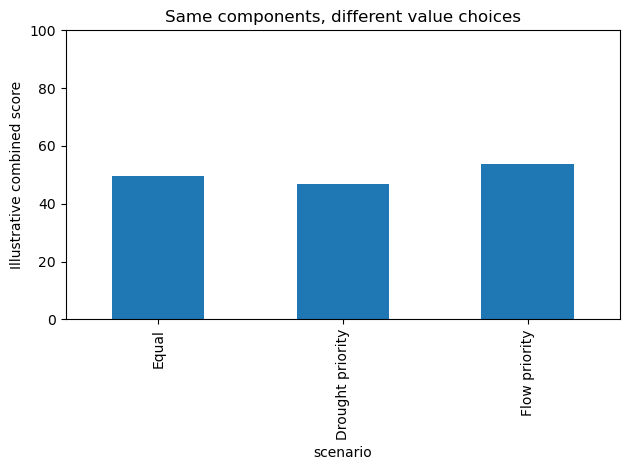

In [8]:
illustrative_scores = {"Drought": 42, "Streamflow": 58, "Temperature": 47, "Precipitation": 52}
weight_scenarios = {
    "Equal": {"Drought": .25, "Streamflow": .25, "Temperature": .25, "Precipitation": .25},
    "Drought priority": {"Drought": .55, "Streamflow": .20, "Temperature": .15, "Precipitation": .10},
    "Flow priority": {"Drought": .15, "Streamflow": .60, "Temperature": .10, "Precipitation": .15},
}
rows = []
for scenario, weights in weight_scenarios.items():
    assert np.isclose(sum(weights.values()), 1)
    rows.append({"scenario": scenario, "combined_score": sum(illustrative_scores[k] * weights[k] for k in weights)})
pd.DataFrame(rows).set_index("scenario").plot.bar(legend=False, ylim=(0, 100), ylabel="Illustrative combined score", title="Same components, different value choices")
plt.tight_layout()
plt.show()

## Sovereignty activity 3: choose the next use (5 minutes)

Imagine a request to post your chart online or reuse it in a project about a different community. What changes in purpose, audience or representation would need review? Discuss an option to revise, limit or decline the proposed use. Who can ask for a correction or withdrawal, and who would act on it?

Record your decision and reason, potential benefit, reviewer roles, storage/access and correction process. You may leave unresolved items as `None` and explain what needs to happen next. Keep real sensitive information out of this exercise.


In [9]:
# CUSTOMIZE: a proposed classroom decision, not an authorization.
governance_notes.update({
    "potential_benefit": None,
    "authority_to_consult": None,
    "reviewer_roles": None,
    "storage_and_access": None,
    "correction_withdrawal": None,
    "decision": None,  # ex., revise the claim; keep within class; seek review before reuse
    "decision_reason": None,
})

## Provenance: technical lineage and governance decisions

This cell records the actual snapshot URLs/dates and verified checksums, notebook identity, analytical settings, limitations and your discussion notes. Review these together: technical correctness alone does not settle authority or appropriate use.

The [IEEE 2890-2025 recommended practice](https://standards.ieee.org/ieee/2890/10318/) addresses provenance relevant to Indigenous Peoples' data relationships and governance. This classroom record explores those ideas; it is not a standards-conformity assessment or evidence of Tribal endorsement. The [framework references](../guides/sovereignty_practice.md) provide further reading.


In [10]:
import sys, json
sys.path.insert(0, str(REPO/"src"))
from provenance import build_provenance, save_draft
source_files = [sorted(DATA.glob(f"usgs_nwis_{site_id}_*.rdb"))[-1].name
                for site_id in flow["site_id"].unique()]
analysis = {
    "source_steward": "USGS",
    "site_ids": sorted(str(x) for x in flow["site_id"].unique()),
    "measure": "annual mean discharge, time-window trends, and separate illustrative weight exercise",
    "units": {"flow": "cubic feet per second", "trend": "cfs per decade", "illustrative_score": "arbitrary teaching scale"},
    "returned_period": [str(flow["date"].min().date()), str(flow["date"].max().date())],
    "requested_comparison_windows": [list(EARLY_WINDOW), list(LATE_WINDOW)],
    "primary_gauge": PRIMARY_GAUGE,
    "completeness_rule": "at least 330 observed days per year; teaching choice",
    "included_station_years": int(coverage["complete_enough"].sum()),
    "excluded_station_years": int((~coverage["complete_enough"]).sum()),
    "processing": ["parse discharge RDB", "remove invalid dates/values", "group by station/year", "compare OLS slopes in chosen windows"],
    "illustrative_scores": illustrative_scores,
    "weight_scenarios": weight_scenarios,
    "limitations": ["qualifier-code review remains needed", "missing days can be seasonal", "gauges are not interchangeable community indicators", "illustrative scores are not observations"],
    "artifact": "in-notebook gauge, trend and illustrative-weight outputs",
}
provenance = build_provenance(REPO, "tracks/02_data_investigator.ipynb", source_files, analysis, governance_notes)
print(json.dumps(provenance, indent=2))
print("Unresolved discussion fields:", provenance["unresolved_fields"])
# Completing fields does not change the classroom-draft status.


{
  "schema_version": "1.0",
  "created_utc": "2026-09-08T19:57:37.969723+00:00",
  "status": "classroom draft: external sharing not approved by this record",
  "technical_lineage": {
    "notebook": "tracks/02_data_investigator.ipynb",
    "notebook_sha256": "ed9572f81a61be9011d00c7acfa2c3403ce192e0fd9bccdf316e07b882d1a66e",
    "provenance_helper_sha256": "41c80a44ab005301bc1787eeb8ba5e8876451d9a3201862c00661ab32cdc88dd",
    "python": "3.12.14",
    "sources": [
      {
        "file": "usgs_nwis_06446000_1990_2024.rdb",
        "url": "https://waterservices.usgs.gov/nwis/dv/?format=rdb&sites=06446000&startDT=1990-01-01&endDT=2024-12-31&parameterCd=00060&statCd=00003",
        "accessed_utc": "2026-08-24T19:51:38.747473+00:00",
        "status": "downloaded",
        "bytes": 419155,
        "sha256": "5309b831d7ede848a5650c3d3c8cb9aa8740395d32ca75e7e033fe7e985bb521",
        "checksum_verified": true
      },
      {
        "file": "usgs_nwis_06446500_1990_2024.rdb",
        "url"

### Optional: save a local draft record

If your notes contain only appropriate classroom information, set `SAVE_DRAFT=True` to save a JSON sidecar under ignored `outputs/governance/`. It describes the in-notebook artifacts; it does not export a figure or publish anything. Use the agreed class storage for completed work. The notebook itself can also retain edited notes but clear private information before sharing the notebook. Re-run the provenance cell after changing analysis settings or notes.


In [11]:
SAVE_DRAFT = False
if SAVE_DRAFT:
    draft_path = save_draft(provenance, REPO/"outputs"/"governance")
    print("Saved local classroom draft:", draft_path)
else:
    print("Draft displayed above; no sidecar saved.")

Draft displayed above; no sidecar saved.


## What to bring to the final presentation

Explain what you tried and learned; show any visualizations and describe their source and meaning. Record uncertainty and future project ideas. Use the seven questions below to prepare.

## Final presentation and stewardship

1. **What question did you explore, and why did it interest you?**
2. **What did you learn?** Describe something about the topic, data or method.
3. **What did you create?** Show any visualizations and explain their source, place, period and meaning. If you did not finish a visualization, explain what you tried and what happened.
4. **What remains uncertain?** Identify a limitation, challenge or unanswered question.
5. **What would you investigate next?** Suggest a future project and the data, skills or partnerships it would need.
6. **Who might benefit from this work?** Explain the potential benefit without claiming an outcome the project has not demonstrated.
7. **Who should review or help interpret this work?** Identify relevant people or roles and why their perspective matters; naming a reviewer does not imply approval.

See the [presentation guidance](../guides/final_presentation.md). Save full stewardship details in the agreed class location. The final hour, September 16 10:45–11:45, is for student sharing and questions.

### Bring your decisions into the seven-question presentation

Use the provenance record to explain sources and limitations (questions 3-4). Explain a future-use decision (question 5), a possible benefit (question 6) and the reviewer roles/perspectives needed (question 7). You can state that a decision remains unresolved. 
